In [123]:
import pandas as pd
from utils import load_data

import matplotlib.pyplot as plt

In [124]:
mmgbsa, top_k_mmgbsa, mmgbsa_source = load_data(f"results/mcl1_mmpbsa_gb_proto_shuffled.sqlite", k_ratio=0.01)
vina, top_k_vina, vina_source = load_data(f"results/mcl1_vina_proto_shuffled.sqlite", k_ratio=0.01)
vina_source = vina_source.drop(columns=["Unnamed: 0"])
vina_source["method"] = "Docking"
mmgbsa_source["method"] = "MMGBSA"

df = pd.concat([mmgbsa_source, vina_source], ignore_index=True)
df = df.sort_values(by="name")
df = df.set_index("name")

Let's also load the experimental values and compare to them

In [ ]:
from rdkit import Chem
docking_experimental = pd.read_csv("../docking/experimental_docking_results.csv", names=["smiles_a", "smiles_b", "target"])
mmgbsa_experimental = pd.read_csv("../data/benchmark_dg_en_gb_avg.csv")

mmgbsa_experimental["smiles_canon"] = mmgbsa_experimental["smiles"].map(Chem.MolFromSmiles).map(Chem.MolToSmiles)

experimental = mmgbsa_experimental.merge(docking_experimental, left_on="smiles_canon", right_on="smiles_a", suffixes=["_mmgbsa", "_docking"])
experimental.drop(columns=["smiles", "smiles_a", "smiles_b", "smiles_canon", "name"])

We plot the top-1% of molecules for both MMGBSA and Docking

In [125]:
top1_docking = df[df["method"] == "Docking"].nsmallest(593, ["target"])
top1_mmgbsa = df[df["method"] == "MMGBSA"].nsmallest(593, ["target"])

overlap = top1_docking.index.intersection(top1_mmgbsa.index)

top1_docking = top1_docking.drop(overlap)
top1_mmgbsa = top1_mmgbsa.drop(overlap)

# We need both docking and mmgbsa values
top1_docking = df.loc[top1_docking.index].pivot(columns=["method"], values=["target"])
top1_mmgbsa = df.loc[top1_mmgbsa.index].pivot(columns=["method"], values=["target"])
top1_overlap = df.loc[overlap].pivot(columns=["method"], values=["target"])

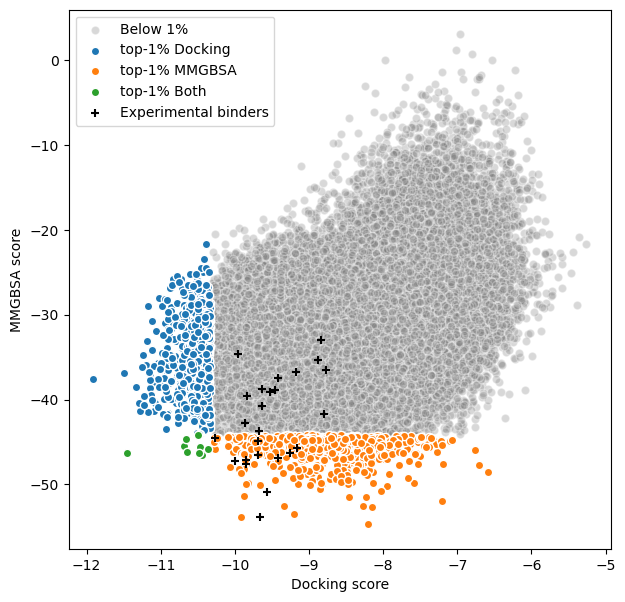

In [188]:
pivot_df = df.pivot(columns=["method"], values=["target"])

plt.scatter(pivot_df[("target", "Docking")], pivot_df[("target", "MMGBSA")], edgecolor="white", color="grey", alpha=0.3, label="Below 1%")

plt.scatter(top1_docking[("target", "Docking")], top1_docking[("target", "MMGBSA")], label="top-1% Docking", edgecolor="white")
plt.scatter(top1_mmgbsa[("target", "Docking")], top1_mmgbsa[("target", "MMGBSA")], label="top-1% MMGBSA", edgecolor="white")
plt.scatter(top1_overlap[("target", "Docking")], top1_overlap[("target", "MMGBSA")], label="top-1% Both", edgecolor="white")

plt.scatter(experimental["target_docking"], experimental["target_mmgbsa"], marker="+", label="Experimental binders", color="k")
plt.xlabel("Docking score")
plt.ylabel("MMGBSA score")
plt.legend()
plt.gcf().set_size_inches(7, 7)
plt.savefig("figures/docking_vs_mmgbsa_top1.png", dpi=300, bbox_inches="tight")

In [192]:
len(overlap) / 593 * 100

1.6863406408094435